In [1]:
import matplotlib.pyplot as plt

from keras.datasets import mnist

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
)

from sklearn.model_selection import(
    train_test_split,
    cross_validate,
    cross_val_score,
    ShuffleSplit
)

from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from sklearn.pipeline import Pipeline

In [2]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

In [3]:
print('Shape of training data', x_train.shape)
print('Shape of training labels', y_train. shape)
print('Shape of testing data', x_test.shape)
print('Shape of testing labels',y_test. shape)

Shape of training data (60000, 28, 28)
Shape of training labels (60000,)
Shape of testing data (10000, 28, 28)
Shape of testing labels (10000,)


In [4]:
x_train = x_train.reshape(x_train.shape[0] , 28*28)
x_test = x_test.reshape(x_test.shape[0] , 28*28)

In [5]:
x_train = x_train/255
x_test = x_test/255

In [6]:
print('Shape of training data after flattening', x_train. shape)
print('Shape of testing data after flattening', x_test. shape)

Shape of training data after flattening (60000, 784)
Shape of testing data after flattening (10000, 784)


In [7]:
cv = ShuffleSplit(n_splits=10 , test_size=0.2 , random_state=42)

In [8]:
def train_classifiers(estimator, X_train, y_train, cv, name) :
    estimator.fit(X_train, y_train)
    cv_train_score = cross_val_score(
        estimator, X_train, y_train,
        cv=cv,scoring='f1_macro'
    )
    print(f"On an average, {name} model has f1 score of "
    f"{cv_train_score.mean() :.3f} +/- {cv_train_score.std() :.3f} on the training set.")

In [9]:
def eval(estimator, X_test, y_test) :
    y_pred = estimator.predict(X_test)

    print("# Classification report")
    print(classification_report(y_test, y_pred) )

    print("# Confusion matrix")
    disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred) )
    disp.plot()
    plt.title('Confusion matrix')
    plt.show()

### MNIST Classification with AdaBoost

In [10]:
abc_pipeline = Pipeline([
    ("classifier", AdaBoostClassifier()) 
])
train_classifiers(
    abc_pipeline, x_train, 
    y_train.ravel(), 
    cv, "AdaBoostClassifier")

KeyboardInterrupt: 

# Classification report
              precision    recall  f1-score   support

           0       0.90      0.60      0.72       980
           1       0.90      0.32      0.48      1135
           2       0.56      0.67      0.61      1032
           3       0.44      0.65      0.53      1010
           4       0.50      0.51      0.50       982
           5       0.46      0.50      0.48       892
           6       0.82      0.70      0.76       958
           7       0.69      0.60      0.64      1028
           8       0.52      0.75      0.62       974
           9       0.43      0.47      0.45      1009

    accuracy                           0.58     10000
   macro avg       0.62      0.58      0.58     10000
weighted avg       0.63      0.58      0.58     10000

# Confusion matrix


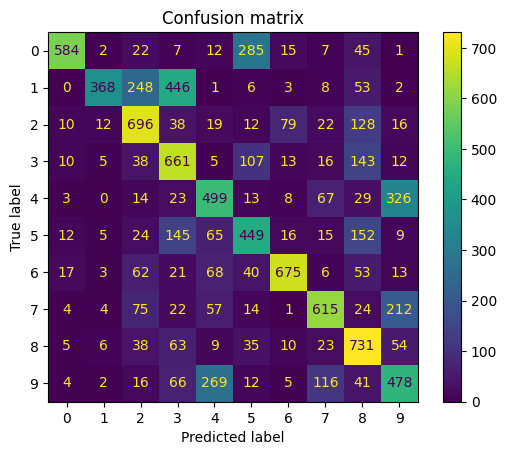

In [ ]:
eval(abc_pipeline, x_test, y_test)

### MNIST Classification with GraidentBoostingClassification

In [ ]:
gbc_pipeline = Pipeline([
    ("classifier", GradientBoostingClassifier(n_estimators=10)) 
])
train_classifiers(
    gbc_pipeline, x_train,y_train.ravel(),
    cv,"GradientBoostingClassifier"
)


In [ ]:
eval(gbc_pipeline, X_test, y_test)

#### MNIST with XGBoostClassifier

In [ ]:
!pip install xgboost

^C


In [ ]:
from xgboost import XGBClassifier

?XGBClassifier



ModuleNotFoundError: No module named 'xgboost'

In [ ]:
xbc_pipeline = Pipeline([
    ("classifier", XGBClassifier())
])
train_classifiers (
    xbc_pipeline, X_train,
    y_train.ravel(), cv,"XGBClassifier"
)

In [ ]:

eval(xbc_pipeline, x_test, y_test)